In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv(
    "European_Bank_Statistically_Validated.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (10000, 47)


In [2]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,Balance_Segment,Salary_Segment,Product_Depth_Group,Engagement_Status,Engagement_Profile,High_Value_Customer,High_Value_Disengaged,Customer_Value_Segment,Credit_Card_Status,Engagement_Score,Initial_Retention_Risk,Balance_to_Salary_Ratio,Financial_Segment,Churn_Status,Final_Engagement_Segment,Recommended_Strategy,Balance_Value_Group,Premium_Risk_Category,Premium_Risk_Score,Premium_Risk_Band,Engagement_Component,Product_Depth_Component,Credit_Card_Component,Financial_Component,Relationship_Strength_Index,Relationship_Strength_Band,RSI_Percentile,Retention_Risk_Score,Retention_Risk_Score_Adjusted,Retention_Risk_Band,Relationship_Classification,Retention_Strategy
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,36-45,Low Balance,High Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Card Holder,70,Low Risk,0.000000,High Salary - Low Balance,Churned,Engaged Growth,Cross-Sell Carefully,Standard Balance,Standard Customer,20,Low,40,10,15,5,70,Moderate,62.825,30,30,Medium Risk,Growth Opportunity,Targeted cross-sell based on customer needs
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,36-45,Medium Balance,High Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Non Card Holder,50,Low Risk,0.744677,High Salary - Low Balance,Retained,Engaged Growth,Cross-Sell Carefully,Standard Balance,Standard Customer,30,Low,40,10,0,5,55,Moderate,48.525,45,45,Medium Risk,Growth Opportunity,Targeted cross-sell based on customer needs
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,36-45,Very High Balance,High Salary,3+ Products,Inactive,Inactive Multi-Product,1,1,High Value - Disengaged,Card Holder,50,High Risk,1.401375,High Salary - High Balance,Churned,Complex / Investigate,Investigate Product-Churn Pattern,High Balance,High Premium Risk,70,High,0,20,15,15,50,Moderate,39.470,50,60,High Risk,At-Risk Premium,Priority proactive retention and relationship ...
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,36-45,Low Balance,Medium Salary,Two Products,Inactive,Inactive Multi-Product,0,0,Standard Value - Disengaged,Non Card Holder,30,Medium Risk,0.000000,Low Salary - Low Balance,Retained,Dormant Relationship,Reactivate,Standard Balance,Standard Customer,40,Medium,0,30,0,5,35,Weak,22.395,65,65,High Risk,Disengaged,Reactivation and engagement campaign
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,36-45,High Balance,Medium Salary,Single Product,Active,Active Low-Product,0,0,Standard Value - Engaged,Card Holder,70,Low Risk,1.587055,Low Salary - High Balance,Retained,Engaged Growth,Cross-Sell Carefully,Standard Balance,Standard Customer,20,Low,40,10,15,5,70,Moderate,62.825,30,30,Medium Risk,Growth Opportunity,Targeted cross-sell based on customer needs


In [3]:
total_customers = len(df)

churned_customers = df["Exited"].sum()

retained_customers = total_customers - churned_customers

overall_churn = df["Exited"].mean() * 100

active_customers = (
    df["IsActiveMember"] == 1
).sum()

inactive_customers = (
    df["IsActiveMember"] == 0
).sum()

high_value_disengaged = (
    df["High_Value_Disengaged"] == 1
).sum()

print("Total Customers:", total_customers)
print("Retained Customers:", retained_customers)
print("Churned Customers:", churned_customers)
print("Overall Churn:", round(overall_churn, 2), "%")
print("Active Customers:", active_customers)
print("Inactive Customers:", inactive_customers)
print(
    "High-Value Disengaged Customers:",
    high_value_disengaged
)

Total Customers: 10000
Retained Customers: 7963
Churned Customers: 2037
Overall Churn: 20.37 %
Active Customers: 5151
Inactive Customers: 4849
High-Value Disengaged Customers: 1247


In [4]:
executive_kpis = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Overall Churn Rate",
        "Active Customer Rate",
        "Inactive Customer Rate",
        "Average Products per Customer",
        "Credit Card Ownership Rate",
        "High-Balance Disengagement Rate",
        "High-Value Disengaged Customers"
    ],
    
    "Value": [
        total_customers,
        round(overall_churn, 2),
        round(
            df["IsActiveMember"].mean() * 100,
            2
        ),
        round(
            (1 - df["IsActiveMember"].mean()) * 100,
            2
        ),
        round(
            df["NumOfProducts"].mean(),
            2
        ),
        round(
            df["HasCrCard"].mean() * 100,
            2
        ),
        round(
            df[
                df["Balance"] >= df["Balance"].quantile(0.75)
            ]["IsActiveMember"].eq(0).mean() * 100,
            2
        ),
        high_value_disengaged
    ]
})

executive_kpis

,KPI,Value
0,Total Customers,10000.00
1,Overall Churn Rate,20.37
2,Active Customer Rate,51.51
3,Inactive Customer Rate,48.49
4,Average Products per Customer,1.53
5,Credit Card Ownership Rate,70.55
6,High-Balance Disengagement Rate,49.88
7,High-Value Disengaged Customers,1247.00


In [5]:
engagement_final = (
    df.groupby("Engagement_Status")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

engagement_final["Churn_Rate"] *= 100

engagement_final

,Engagement_Status,Customers,Churned,Churn_Rate
0,Active,5151,735,14.269074
1,Inactive,4849,1302,26.850897


In [6]:

active_churn = (
    df.loc[
        df["IsActiveMember"] == 1,
        "Exited"
    ].mean() * 100
)

inactive_churn = (
    df.loc[
        df["IsActiveMember"] == 0,
        "Exited"
    ].mean() * 100
)

engagement_gap = inactive_churn - active_churn

print(
    "Inactive vs Active churn gap:",
    round(engagement_gap, 2),
    "percentage points"
)

Inactive vs Active churn gap: 12.58 percentage points


In [7]:
product_final = (
    df.groupby("NumOfProducts")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

product_final["Churn_Rate"] *= 100

product_final

,NumOfProducts,Customers,Churned,Churn_Rate
0,1,5084,1409,27.714398
1,2,4590,348,7.581699
2,3,266,220,82.706767
3,4,60,60,100.000000


In [9]:
premium_final = (
    df[
        df["High_Value_Disengaged"] == 1
    ]
)

premium_churn = (
    premium_final["Exited"].mean() * 100
)

premium_count = len(premium_final)

print("High-Value Disengaged Customers:", premium_count)
print(
    "High-Value Disengaged Churn:",
    round(premium_churn, 2),
    "%"
)

High-Value Disengaged Customers: 1247
High-Value Disengaged Churn: 30.47 %


In [10]:
rsi_final = (
    df.groupby("Relationship_Strength_Band")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Average_RSI=(
            "Relationship_Strength_Index",
            "mean"
        )
    )
    .reset_index()
)

rsi_final["Churn_Rate"] *= 100

rsi_final

,Relationship_Strength_Band,Customers,Churned,Churn_Rate,Average_RSI
0,Moderate,3586,598,16.675962,59.498048
1,Strong,3107,314,10.106212,85.775668
2,Very Weak,495,185,37.373737,15.070707
3,Weak,2812,940,33.428165,33.534851


In [12]:
risk_final = (
    df.groupby("Retention_Risk_Band")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Actual_Churn_Rate=("Exited", "mean"),
        Average_Risk_Score=(
            "Retention_Risk_Score_Adjusted",
            "mean"
        )
    )
    .reset_index()
)

risk_final["Actual_Churn_Rate"] *= 100

risk_final

,Retention_Risk_Band,Customers,Churned,Actual_Churn_Rate,Average_Risk_Score
0,Critical Risk,768,294,38.281250,84.407552
1,High Risk,4081,1008,24.699828,61.518010
2,Low Risk,2489,265,10.646846,11.548815
3,Medium Risk,2662,470,17.655898,32.389181


In [13]:
top_drivers = pd.DataFrame({
    "Rank": [1, 2, 3, 4, 5],
    
    "Driver": [
        "Customer Engagement",
        "Product Relationship Depth",
        "High-Value Disengagement",
        "Relationship Strength",
        "Credit Card / Product Relationship"
    ],
    
    "Business Signal": [
        "Inactive customers show substantially higher churn",
        "Two-product customers show much lower churn than single-product customers",
        "High-balance inactive customers show elevated churn",
        "Weaker relationship strength corresponds to greater retention risk",
        "Product ownership provides an additional relationship signal"
    ]
})

top_drivers

,Rank,Driver,Business Signal
0,1,Customer Engagement,Inactive customers show substantially higher c...
1,2,Product Relationship Depth,Two-product customers show much lower churn th...
2,3,High-Value Disengagement,High-balance inactive customers show elevated ...
3,4,Relationship Strength,Weaker relationship strength corresponds to gr...
4,5,Credit Card / Product Relationship,Product ownership provides an additional relat...


In [14]:
priority_segment_summary = (
    df.groupby("Relationship_Classification")
    .agg(
        Customers=("CustomerId", "count"),
        Churned=("Exited", "sum"),
        Churn_Rate=("Exited", "mean"),
        Avg_Balance=("Balance", "mean"),
        Avg_Products=("NumOfProducts", "mean"),
        Avg_RSI=(
            "Relationship_Strength_Index",
            "mean"
        )
    )
    .reset_index()
)

priority_segment_summary["Churn_Rate"] *= 100

priority_segment_summary.round(2)

,Relationship_Classification,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Products,Avg_RSI
0,At-Risk Premium,1247,380,30.47,148857.68,1.38,42.10
1,Developing Relationship,658,81,12.31,38341.20,2.12,74.41
2,Disengaged,3602,922,25.60,52304.02,1.57,35.81
3,Growth Opportunity,2004,389,19.41,85072.32,1.00,65.38
4,Strong Relationship,2489,265,10.65,78393.28,1.81,88.45


In [15]:
strategy_framework = pd.DataFrame({
    "Customer Segment": [
        "Strong Relationship",
        "Growth Opportunity",
        "At-Risk Premium",
        "Disengaged",
        "Complex / Investigate"
    ],
    
    "Primary Risk / Opportunity": [
        "Low immediate churn risk",
        "Relationship depth is limited",
        "Financially valuable but inactive",
        "Weak engagement and relationship",
        "Unusually high churn among 3+ product customers"
    ],
    
    "Recommended Action": [
        "Loyalty rewards and relationship maintenance",
        "Need-based cross-sell and product bundling",
        "Proactive retention outreach",
        "Reactivation and engagement campaigns",
        "Root-cause investigation and product review"
    ],
    
    "Priority": [
        "Medium",
        "High",
        "Very High",
        "High",
        "Very High"
    ]
})

strategy_framework

,Customer Segment,Primary Risk / Opportunity,Recommended Action,Priority
0,Strong Relationship,Low immediate churn risk,Loyalty rewards and relationship maintenance,Medium
1,Growth Opportunity,Relationship depth is limited,Need-based cross-sell and product bundling,High
2,At-Risk Premium,Financially valuable but inactive,Proactive retention outreach,Very High
3,Disengaged,Weak engagement and relationship,Reactivation and engagement campaigns,High
4,Complex / Investigate,Unusually high churn among 3+ product customers,Root-cause investigation and product review,Very High


In [16]:
action_matrix = pd.DataFrame({
    "Segment": [
        "At-Risk Premium",
        "Disengaged",
        "Growth Opportunity",
        "Strong Relationship",
        "Complex / Investigate"
    ],
    
    "Trigger": [
        "High balance + inactive",
        "Inactive + low product depth",
        "Active + single product",
        "Active + strong relationship",
        "3+ products + abnormal churn pattern"
    ],
    
    "Recommended Action": [
        "Dedicated retention outreach and personalized relationship management",
        "Digital reactivation, engagement nudges and targeted offers",
        "Needs-based cross-sell to increase relationship depth",
        "Loyalty benefits and proactive service engagement",
        "Investigate product combinations, service issues and customer experience"
    ],
    
    "Success KPI": [
        "Reactivation rate",
        "Active-member conversion",
        "Product adoption rate",
        "Retention rate",
        "Churn reduction"
    ]
})

action_matrix

,Segment,Trigger,Recommended Action,Success KPI
0,At-Risk Premium,High balance + inactive,Dedicated retention outreach and personalized ...,Reactivation rate
1,Disengaged,Inactive + low product depth,"Digital reactivation, engagement nudges and ta...",Active-member conversion
2,Growth Opportunity,Active + single product,Needs-based cross-sell to increase relationshi...,Product adoption rate
3,Strong Relationship,Active + strong relationship,Loyalty benefits and proactive service engagement,Retention rate
4,Complex / Investigate,3+ products + abnormal churn pattern,"Investigate product combinations, service issu...",Churn reduction


In [17]:
priority_customers = df[
    (
        df["High_Value_Disengaged"] == 1
    )
    |
    (
        df["Retention_Risk_Band"] == "Critical Risk"
    )
].copy()

print(
    "Immediate priority customers:",
    len(priority_customers)
)

Immediate priority customers: 1773


In [18]:
secondary_priority = df[
    (
        df["Retention_Risk_Band"] == "High Risk"
    )
    &
    (
        df["High_Value_Disengaged"] == 0
    )
].copy()

print(
    "Secondary priority customers:",
    len(secondary_priority)
)

Secondary priority customers: 3076


In [19]:
final_executive_summary = pd.DataFrame({
    "Area": [
        "Customer Base",
        "Engagement",
        "Product Depth",
        "Financial Value",
        "Relationship Strength",
        "Retention Risk"
    ],
    
    "Key Finding": [
        f"{total_customers:,} customer records analyzed",
        "Inactive customers exhibit materially higher churn",
        "Two-product customers show substantially lower churn than single-product customers",
        "High-balance inactive customers represent an elevated-risk premium segment",
        "Relationship strength provides a practical customer-level retention indicator",
        "Risk bands can prioritize customers for proactive intervention"
    ],
    
    "Management Implication": [
        "Use customer-level segmentation rather than blanket retention campaigns",
        "Treat inactivity as an early-warning indicator",
        "Develop targeted product-bundling and cross-sell strategies",
        "Prioritize premium customers with declining engagement",
        "Use relationship strength alongside financial value",
        "Direct retention resources toward highest-risk segments"
    ]
})

final_executive_summary

,Area,Key Finding,Management Implication
0,Customer Base,"10,000 customer records analyzed",Use customer-level segmentation rather than bl...
1,Engagement,Inactive customers exhibit materially higher c...,Treat inactivity as an early-warning indicator
2,Product Depth,Two-product customers show substantially lower...,Develop targeted product-bundling and cross-se...
3,Financial Value,High-balance inactive customers represent an e...,Prioritize premium customers with declining en...
4,Relationship Strength,Relationship strength provides a practical cus...,Use relationship strength alongside financial ...
5,Retention Risk,Risk bands can prioritize customers for proact...,Direct retention resources toward highest-risk...


In [20]:
insight_cards = {
    "Overall Churn": f"{overall_churn:.2f}%",
    
    "Inactive Customer Churn": f"{inactive_churn:.2f}%",
    
    "Active Customer Churn": f"{active_churn:.2f}%",
    
    "High-Value Disengaged": f"{premium_count:,}",
    
    "Premium Segment Churn": f"{premium_churn:.2f}%",
    
    "Average Products": f"{df['NumOfProducts'].mean():.2f}"
}

insight_cards

{'Overall Churn': '20.37%',
 'Inactive Customer Churn': '26.85%',
 'Active Customer Churn': '14.27%',
 'High-Value Disengaged': '1,247',
 'Premium Segment Churn': '30.47%',
 'Average Products': '1.53'}

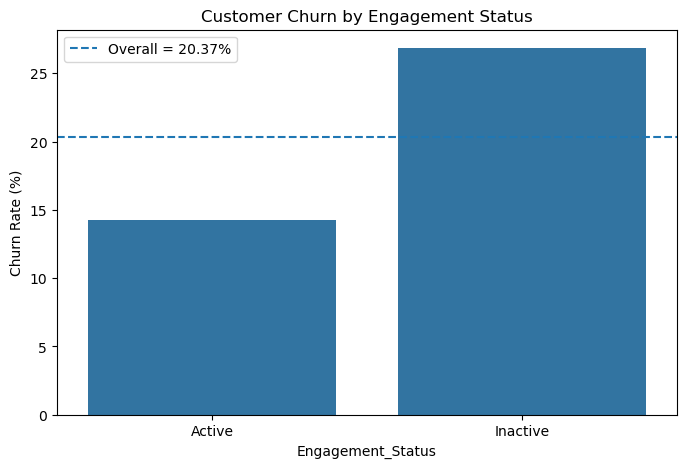

In [21]:
##Chart 1 — Engagement vs churn
plt.figure(figsize=(8, 5))

sns.barplot(
    data=engagement_final,
    x="Engagement_Status",
    y="Churn_Rate"
)

plt.axhline(
    overall_churn,
    linestyle="--",
    label=f"Overall = {overall_churn:.2f}%"
)

plt.title("Customer Churn by Engagement Status")
plt.ylabel("Churn Rate (%)")
plt.legend()

plt.show()

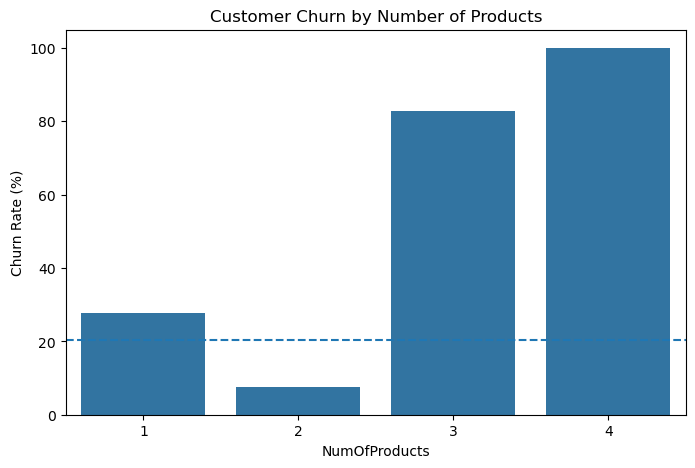

In [22]:
##Chart 2 — Product count vs churn
plt.figure(figsize=(8, 5))

sns.barplot(
    data=product_final,
    x="NumOfProducts",
    y="Churn_Rate"
)

plt.axhline(
    overall_churn,
    linestyle="--"
)

plt.title("Customer Churn by Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

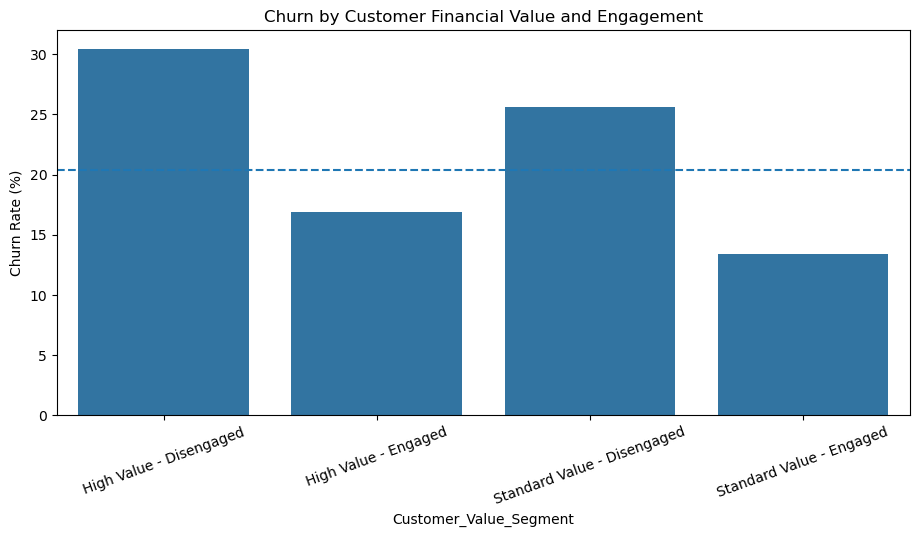

In [23]:
##Chart 3 — High-value vs engagement
value_engagement = (
    df.groupby("Customer_Value_Segment")
    .agg(
        Customers=("CustomerId", "count"),
        Churn_Rate=("Exited", "mean")
    )
    .reset_index()
)

value_engagement["Churn_Rate"] *= 100

plt.figure(figsize=(11, 5))

sns.barplot(
    data=value_engagement,
    x="Customer_Value_Segment",
    y="Churn_Rate"
)

plt.axhline(
    overall_churn,
    linestyle="--"
)

plt.title(
    "Churn by Customer Financial Value and Engagement"
)

plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

plt.show()

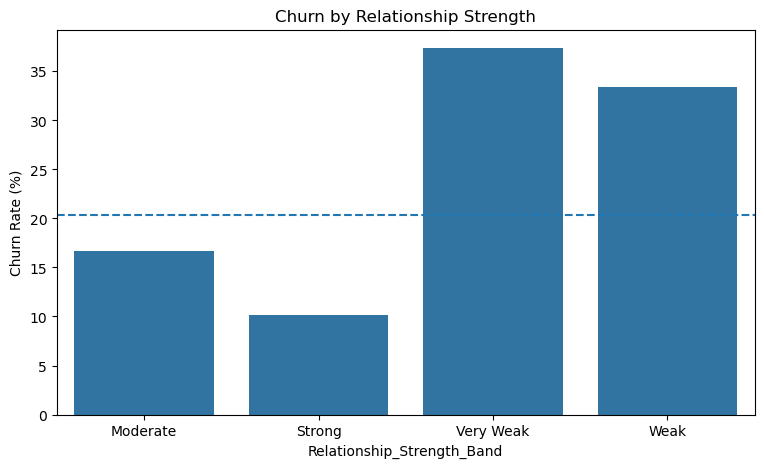

In [24]:
##Chart 4 — Relationship strength vs churn
plt.figure(figsize=(9, 5))

sns.barplot(
    data=rsi_final,
    x="Relationship_Strength_Band",
    y="Churn_Rate"
)

plt.axhline(
    overall_churn,
    linestyle="--"
)

plt.title(
    "Churn by Relationship Strength"
)

plt.ylabel("Churn Rate (%)")

plt.show()

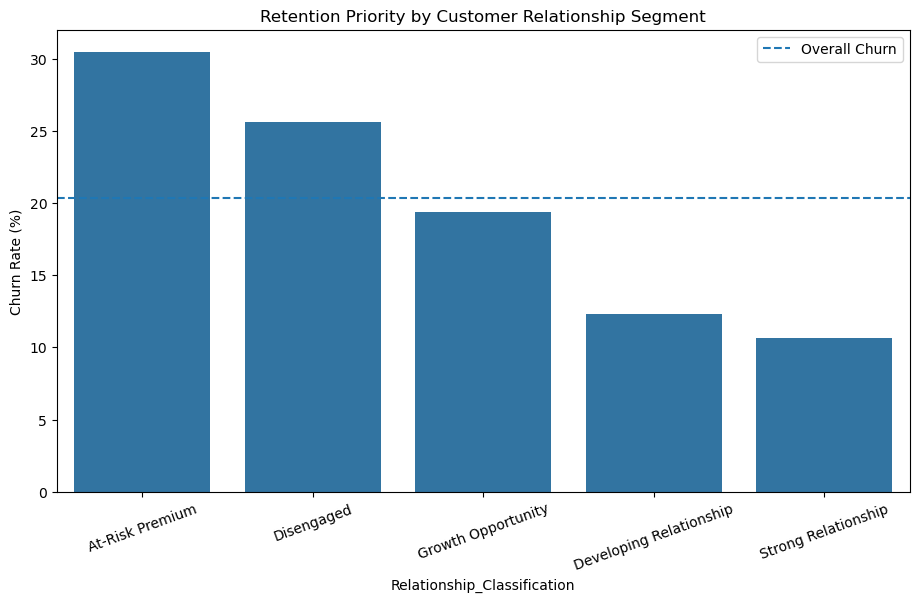

In [25]:
plot_priority = (
    priority_segment_summary
    .sort_values(
        "Churn_Rate",
        ascending=False
    )
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_priority,
    x="Relationship_Classification",
    y="Churn_Rate"
)

plt.axhline(
    overall_churn,
    linestyle="--",
    label="Overall Churn"
)

plt.title(
    "Retention Priority by Customer Relationship Segment"
)

plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)
plt.legend()

plt.show()

In [26]:
recommendation_table = pd.DataFrame({
    "Priority": [1, 2, 3, 4, 5],
    
    "Recommendation": [
        "Launch engagement-based early-warning monitoring",
        "Implement need-based cross-sell for active single-product customers",
        "Create a premium high-balance disengagement watchlist",
        "Develop segmented reactivation campaigns",
        "Investigate the abnormal 3–4 product churn pattern"
    ],
    
    "Primary Segment": [
        "Inactive Customers",
        "Active Single-Product",
        "High-Value Disengaged",
        "Disengaged Customers",
        "3+ Product Customers"
    ],
    
    "Expected Business Benefit": [
        "Earlier churn intervention",
        "Greater relationship depth",
        "Protect high-value relationships",
        "Increase customer engagement",
        "Identify hidden product/service problems"
    ]
})

recommendation_table

,Priority,Recommendation,Primary Segment,Expected Business Benefit
0,1,Launch engagement-based early-warning monitoring,Inactive Customers,Earlier churn intervention
1,2,Implement need-based cross-sell for active sin...,Active Single-Product,Greater relationship depth
2,3,Create a premium high-balance disengagement wa...,High-Value Disengaged,Protect high-value relationships
3,4,Develop segmented reactivation campaigns,Disengaged Customers,Increase customer engagement
4,5,Investigate the abnormal 3–4 product churn pat...,3+ Product Customers,Identify hidden product/service problems


In [27]:
executive_kpis.to_csv(
    "Final_Executive_KPIs.csv",
    index=False
)

final_executive_summary.to_csv(
    "Final_Executive_Summary.csv",
    index=False
)

strategy_framework.to_csv(
    "Retention_Strategy_Framework.csv",
    index=False
)

action_matrix.to_csv(
    "Retention_Action_Matrix.csv",
    index=False
)

recommendation_table.to_csv(
    "Final_Business_Recommendations.csv",
    index=False
)

priority_segment_summary.to_csv(
    "Final_Priority_Segment_Summary.csv",
    index=False
)

print("✅ All Step 8 outputs saved successfully.")

✅ All Step 8 outputs saved successfully.


In [28]:
df.to_csv(
    "European_Bank_Final_Analytics_Dataset.csv",
    index=False
)

print(
    "✅ Final analytics dataset created."
)

✅ Final analytics dataset created.
